# 🚆 Railway Delay Analysis Project

## 📌 Project Overview

Excited to share my Railway Delay Analysis Project, where I explored railway operational data to uncover patterns, trends, and factors affecting train punctuality. Through data cleaning, exploratory data analysis, and visualization, I analyzed delays across different routes, seasons, and travel distances to gain meaningful insights into railway performance.

## 🎯 Project Objectives

The primary goal of this project is to understand train delay behavior and identify the factors that influence railway operations. By analyzing historical railway data, this project aims to evaluate train performance, discover delay trends, compare route efficiency, and generate insights that can support better decision-making and operational planning.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 📂 Load Dataset

In [2]:
df = pd.read_csv("Railway data.csv")

In [3]:
df.shape

(100, 12)

In [4]:
df.columns

Index(['Train_id', 'Train_name', 'Train_no', 'Source', 'Destitnation', 'Date',
       'Distance(Km)', 'Sc_arr__time', 'Act_arr_time', 'Dealy_min', 'Season',
       'Run_frequency'],
      dtype='object')

In [5]:
df.head(2)

,Train_id,Train_name,Train_no,Source,Destitnation,Date,Distance(Km),Sc_arr__time,Act_arr_time,Dealy_min,Season,Run_frequency
0,E1,Begampura Express,12238.0,Varanasi,Jammu,01-01-2016 00:00,1260,06:30:00,07:45:00,01:15:00,Winter,Daliy
1,E2,Begampura Express,12238.0,Varanasi,Jammu,01-01-2017 00:00,1260,06:30:00,06:50:00,00:20:00,Winter,Daliy


## 🔍 Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Train_id       98 non-null     object 
 1   Train_name     100 non-null    object 
 2   Train_no       99 non-null     float64
 3   Source         99 non-null     object 
 4   Destitnation   100 non-null    object 
 5   Date           100 non-null    object 
 6   Distance(Km)   100 non-null    int64  
 7   Sc_arr__time   100 non-null    object 
 8   Act_arr_time   100 non-null    object 
 9   Dealy_min      100 non-null    object 
 10  Season         98 non-null     object 
 11  Run_frequency  100 non-null    object 
dtypes: float64(1), int64(1), object(10)
memory usage: 9.5+ KB


In [7]:
df.describe()

,Train_no,Distance(Km)
count,99.000000,100.000000
mean,14031.646465,1511.900000
std,3226.071998,998.782233
min,12002.000000,491.000000
25%,12238.000000,742.000000
50%,12604.000000,1301.000000
75%,15029.000000,1754.000000
max,22832.000000,4198.000000


In [8]:
df.duplicated().sum()

0

### Duplicate Records Analysis

No duplicate records were found in the dataset. Therefore, no duplicate removal was required.

In [9]:
df.isnull().sum()

Train_id         2
Train_name       0
Train_no         1
Source           1
Destitnation     0
Date             0
Distance(Km)     0
Sc_arr__time     0
Act_arr_time     0
Dealy_min        0
Season           2
Run_frequency    0
dtype: int64

### Handling Missing Values

A small number of missing values were found in Train_id, Train_no, Source, and Season columns. Since these fields are important for analysis and the number of missing records was very low, the corresponding rows were removed.

## 🧹 Data Cleaning & Preprocessing

In [10]:
df["Train_name"].nunique()

10

In [11]:
df = df.dropna(subset=["Train_no"])

In [12]:
df = df.dropna(subset=["Source"])

In [13]:
df = df.dropna(subset=["Season"])

In [14]:
df = df.dropna(subset=["Train_id"])

In [15]:
df.isnull().sum()

Train_id         0
Train_name       0
Train_no         0
Source           0
Destitnation     0
Date             0
Distance(Km)     0
Sc_arr__time     0
Act_arr_time     0
Dealy_min        0
Season           0
Run_frequency    0
dtype: int64

### Final Cleaned Dataset Overview

The dataset was cleaned by handling missing values and verifying duplicate records. The cleaned dataset is now ready for Exploratory Data Analysis (EDA).

-----------------------------------------------

## 📊 Exploratory Data Analysis (EDA)

### 🚉 Train Analysis

- Calculated total unique trains.
- Identified the most frequent trains.
- Analyzed train occurrence distribution.
- Examined least frequent train records.

### Important Keys
- How many unique trains exist in the dataset?
- Which train appears most frequently?
- Which trains appear least frequently?

In [16]:
df["Train_name"].nunique()

10

In [17]:
df["Train_name"].value_counts()

Train_name
Rajdhani Express                 10
Chennai Express                  10
Shatabdi Express                 10
Kanyakumari Express              10
Begampura Express                 9
Gorakhpur-pune Weekly Express     9
Garib Rath Express                9
Lucknow Mail                      9
Yesvantpur–Howrah Express         9
Vivek Express                     9
Name: count, dtype: int64

In [18]:
df["Train_name"].value_counts().head(3)

Train_name
Rajdhani Express     10
Chennai Express      10
Shatabdi Express     10
Name: count, dtype: int64

In [19]:
df["Train_name"].value_counts().tail(3)

Train_name
Lucknow Mail                 9
Yesvantpur–Howrah Express    9
Vivek Express                9
Name: count, dtype: int64

--------------------------------------------------------

### ⏱️ Delay Analysis

- Calculated average delay.
- Identified maximum delay.
- Identified minimum delay.
- Converted delay values into minutes for statistical analysis.


In [20]:
df["Dealy_min"].dtype

dtype('O')

In [21]:
df["Dealy_min"].head(10)

0     01:15:00
1     00:20:00
2     01:30:00
3     00:10:00
4     00:30:00
5     00:05:00
6     00:40:00
8     00:15:00
9     00:50:00
10    01:20:00
Name: Dealy_min, dtype: object

In [22]:
df["Dealy_min"].unique()

array(['01:15:00', '00:20:00', '01:30:00', '00:10:00', '00:30:00',
       '00:05:00', '00:40:00', '00:15:00', '00:50:00', '01:20:00',
       '00:45:00', '01:00:00', '00:35:00', '01:10:00', '00:25:00',
       '00:23:00', '00:11:00', '01:40:00', '02:10:00', '00:09:00',
       '00:01:00', '00:14:00', '00:29:00', '00:34:00', '00:00:00',
       '00:03:00', '00:55:00', '01:05:00', '00:39:00', '20-01-1900 00:20',
       '04:04:00', '03:08:00', '01:03:00', '00:22:00', '00:31:00'],
      dtype=object)

In [23]:
df = df[df["Dealy_min"] != "20-01-1900 00:20"]

In [24]:
dealy = pd.to_timedelta(df["Dealy_min"])
df["Dealy_minutes"] = dealy.dt.total_seconds() / 60

In [25]:
df["Dealy_min"].unique()

array(['01:15:00', '00:20:00', '01:30:00', '00:10:00', '00:30:00',
       '00:05:00', '00:40:00', '00:15:00', '00:50:00', '01:20:00',
       '00:45:00', '01:00:00', '00:35:00', '01:10:00', '00:25:00',
       '00:23:00', '00:11:00', '01:40:00', '02:10:00', '00:09:00',
       '00:01:00', '00:14:00', '00:29:00', '00:34:00', '00:00:00',
       '00:03:00', '00:55:00', '01:05:00', '00:39:00', '04:04:00',
       '03:08:00', '01:03:00', '00:22:00', '00:31:00'], dtype=object)

In [26]:
df["Dealy_minutes"].head()

0    75.0
1    20.0
2    90.0
3    10.0
4    30.0
Name: Dealy_minutes, dtype: float64

In [27]:
df["Dealy_minutes"].mean()

36.54838709677419

In [28]:
df["Dealy_minutes"].min()

0.0

In [29]:
df["Dealy_minutes"].max()

244.0

### 🛤️ Route Analysis
- Most Common Routes
- Route-wise Records
- Best Performing Routes
- Worst Performing Routes

In [30]:
df["Source"].value_counts()

Source
Howrah            10
Mumbai            10
 New Delhi        10
Chennai Egmore    10
Varanasi           9
Gorakhpur          9
 Kolkata           9
Lucknow            9
Dibrugarh          9
Yesvantpur Jn      8
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 5 Most Common Source Stations')

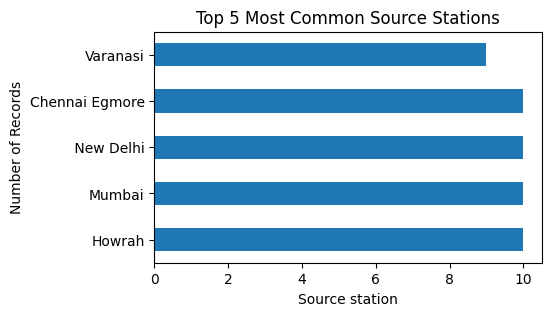

In [88]:
plt.figure(figsize=(5,3))
df["Source"].value_counts().head(5).plot(kind="barh")
plt.xlabel("Source station")
plt.ylabel("Number of Records")
plt.title("Top 5 Most Common Source Stations")

In [32]:
df.groupby("Source")["Dealy_minutes"].mean()

Source
 Kolkata          30.444444
 New Delhi        38.900000
Chennai Egmore    27.200000
Dibrugarh         22.666667
Gorakhpur         40.555556
Howrah            38.500000
Lucknow           26.111111
Mumbai            37.500000
Varanasi          37.222222
Yesvantpur Jn     70.625000
Name: Dealy_minutes, dtype: float64

In [33]:
df.groupby("Source")["Dealy_minutes"].min()

Source
 Kolkata           5.0
 New Delhi         5.0
Chennai Egmore     0.0
Dibrugarh          1.0
Gorakhpur         10.0
Howrah             5.0
Lucknow            1.0
Mumbai             5.0
Varanasi           5.0
Yesvantpur Jn      0.0
Name: Dealy_minutes, dtype: float64

In [34]:
df.groupby("Source")["Dealy_minutes"].max() 

Source
 Kolkata          100.0
 New Delhi        130.0
Chennai Egmore     65.0
Dibrugarh          63.0
Gorakhpur          80.0
Howrah             75.0
Lucknow            70.0
Mumbai             75.0
Varanasi           90.0
Yesvantpur Jn     244.0
Name: Dealy_minutes, dtype: float64

## 🚉 Destination Analysis

The analysis shows the most common destination stations in the dataset. The station with the highest frequency appears as the destination for the largest number of train records.

In [35]:
df["Destitnation"].value_counts()

Destitnation
 New Delhi         28
Kanyakumari        19
Chennai            10
RANI KAMLAPATI     10
Jammu               9
Pune                9
Howrah              8
Name: count, dtype: int64

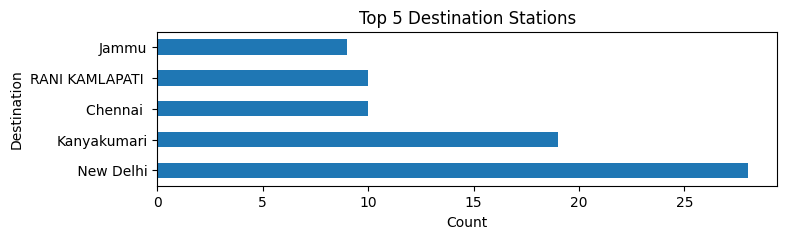

In [93]:
plt.figure(figsize=(8,2))

df["Destitnation"].value_counts().head(5).plot(kind="barh")

plt.title("Top 5 Destination Stations")
plt.xlabel("Count")
plt.ylabel("Destination")
plt.show()

In [37]:
df.groupby("Destitnation")["Dealy_minutes"].mean()

Destitnation
 New Delhi         31.928571
Chennai            37.500000
Howrah             70.625000
Jammu              37.222222
Kanyakumari        25.052632
Pune               40.555556
RANI KAMLAPATI     38.900000
Name: Dealy_minutes, dtype: float64

In [38]:
df.columns

Index(['Train_id', 'Train_name', 'Train_no', 'Source', 'Destitnation', 'Date',
       'Distance(Km)', 'Sc_arr__time', 'Act_arr_time', 'Dealy_min', 'Season',
       'Run_frequency', 'Dealy_minutes'],
      dtype='object')

## 🛤️ Route Analysis

In this section, a new Route feature was created by combining the Source and Destination stations. The objective was to identify the most frequently used railway routes and analyze route-wise delay patterns.



In [39]:
df["Route"] = df["Source"] + "-" + df["Destitnation"]

In [41]:
df["Route"].head(5)

0    Varanasi-Jammu
1    Varanasi-Jammu
2    Varanasi-Jammu
3    Varanasi-Jammu
4    Varanasi-Jammu
Name: Route, dtype: object

---

### Most Common Routes

The frequency of each route was calculated to determine the most commonly occurring railway corridors in the dataset.

In [42]:
df["Route"].value_counts()

Route
Howrah- New Delhi             10
Mumbai-Chennai                10
 New Delhi-RANI KAMLAPATI     10
Chennai Egmore-Kanyakumari    10
Varanasi-Jammu                 9
Gorakhpur-Pune                 9
 Kolkata- New Delhi            9
Lucknow- New Delhi             9
Dibrugarh-Kanyakumari          9
Yesvantpur Jn-Howrah           8
Name: count, dtype: int64

Text(0, 0.5, 'Route Names')

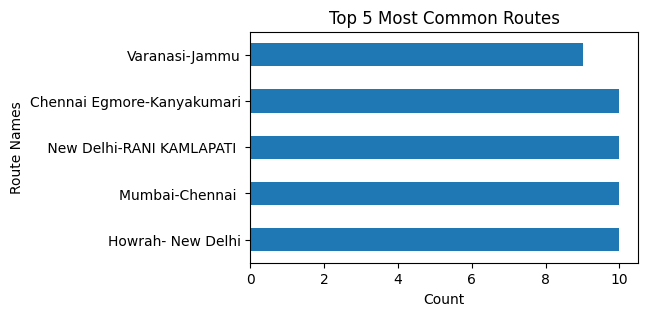

In [87]:
plt.figure(figsize=(5,3))
df["Route"].value_counts().head(5).plot(kind="barh")
plt.title("Top 5 Most Common Routes")
plt.xlabel("Count")
plt.ylabel("Route Names")


---

### Top Delayed Routes

The average delay was calculated for each route to identify routes with poor punctuality performance

In [54]:
df.groupby("Route")["Dealy_minutes"].mean().sort_values(ascending=False)

Route
Yesvantpur Jn-Howrah          70.625000
Gorakhpur-Pune                40.555556
 New Delhi-RANI KAMLAPATI     38.900000
Howrah- New Delhi             38.500000
Mumbai-Chennai                37.500000
Varanasi-Jammu                37.222222
 Kolkata- New Delhi           30.444444
Chennai Egmore-Kanyakumari    27.200000
Lucknow- New Delhi            26.111111
Dibrugarh-Kanyakumari         22.666667
Name: Dealy_minutes, dtype: float64

Text(0, 0.5, 'Route')

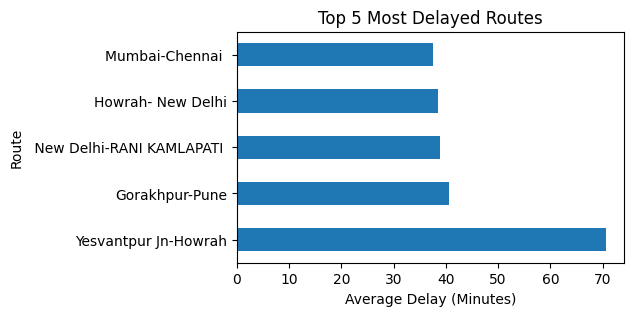

In [90]:
plt.figure(figsize=(5,3))
df.groupby("Route")["Dealy_minutes"].mean().sort_values(ascending=False).head(5).plot(kind="barh")
plt.title("Top 5 Most Delayed Routes")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Route")

### Minimum Dealy Route

In [72]:
df.groupby("Route")["Dealy_minutes"].min().sort_values(ascending=True)

Route
Chennai Egmore-Kanyakumari     0.0
Yesvantpur Jn-Howrah           0.0
Dibrugarh-Kanyakumari          1.0
Lucknow- New Delhi             1.0
 Kolkata- New Delhi            5.0
 New Delhi-RANI KAMLAPATI      5.0
Howrah- New Delhi              5.0
Mumbai-Chennai                 5.0
Varanasi-Jammu                 5.0
Gorakhpur-Pune                10.0
Name: Dealy_minutes, dtype: float64

---

## 🕒 Arrival Time Analysis

In [60]:
df['Hour'] = pd.to_datetime(df['Act_arr_time'], format='%H:%M:%S').dt.hour

In [62]:
def get_time_category(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'
df['Time_Slot'] = df['Hour'].apply(get_time_category)

In [65]:
df["Time_Slot"].value_counts()

Time_Slot
Morning    71
Evening    18
Night       4
Name: count, dtype: int64

### Time slot wise average dealy

In [69]:
df.groupby("Time_Slot")["Dealy_minutes"].mean().sort_values(ascending=False)

Time_Slot
Morning    40.563380
Evening    26.444444
Night      10.750000
Name: Dealy_minutes, dtype: float64

# 📏 Distance Analysis

In [73]:
df["Distance(Km)"].min()

491

In [74]:
df["Distance(Km)"].max()

4198

In [77]:
df['Distance(Km)'].corr(df['Dealy_minutes'])

-0.01819240676293359

### Observation

The correlation between Distance and Delay Minutes is -0.018, which is very close to zero. This indicates that there is no significant relationship between train distance and arrival delay. Both short-distance and long-distance trains experience delays, suggesting that factors other than distance have a greater impact on train punctuality.

# 🔁 Run Frequency Analysis

In [79]:
df["Run_frequency"].value_counts()

Run_frequency
Daliy          66
Weekly         18
 Tri-Weekly     9
Name: count, dtype: int64

In [81]:
df.groupby("Run_frequency")["Dealy_minutes"].mean()

Run_frequency
Daliy          38.727273
Weekly         31.611111
 Tri-Weekly    30.444444
Name: Dealy_minutes, dtype: float64

Text(0, 0.5, 'Run Frequency')

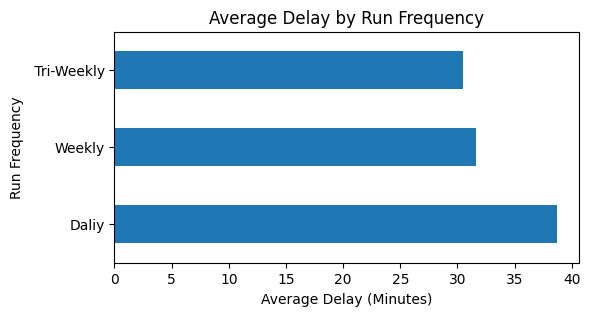

In [92]:
plt.figure(figsize=(6,3))
df.groupby("Run_frequency")["Dealy_minutes"].mean().plot(kind = "barh")
plt.title("Average Delay by Run Frequency")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Run Frequency")


### Observation

The average delay varies across different train frequencies. Certain frequency categories show higher delays, indicating that scheduling patterns may influence train punctuality.

# Key Insights

- Average train delay was **36.55 minutes**.
- Maximum recorded delay was **244 minutes**.
- A few stations and routes handled most of the train traffic.
- Some routes experienced significantly higher delays than others.
- Morning arrivals had the highest average delay (**40.56 min**).
- Night arrivals had the lowest average delay (**10.75 min**).
- Distance and delay showed almost no relationship (**correlation = -0.018**).
- Daily trains recorded higher average delays than Weekly and Tri-Weekly services.

# Recommendations

- Focus on routes with consistently high delays.
- Improve scheduling during morning operations.
- Monitor daily train services more closely.
- Identify and address route-specific bottlenecks.
- Use delay analytics for better timetable planning.